# 实验五：注意力机制与 Transformer

**课程**：深度学习导论
**类型**：作业型实验（理论推导 + 关键算子复现 + 预训练模型探查）
**输出**：从概率语言建模到自注意力的范式综述、Scaled Dot-Product Attention 与多头注意力的纯净实现、Sinusoidal 位置编码可视化、预训练 BERT 的注意力分布观察、6 段段落式书面论证

---

**AI使用说明**：本实验允许并鼓励负责任地使用 AI 辅助理解、查文档、调试、润色表达。不设抽查答辩、不禁止长段 AI 生成。


## 1. 环境与依赖

- 包：`torch`、`transformers`（HuggingFace）、`matplotlib`、`numpy`。
- 数据：文本语料；预训练 BERT 由 `transformers` 在线或本地缓存加载。
- 模式：本 Notebook 不进行任何模型训练，仅做前向计算、注意力提取与可视化。
- 算力：若有 GPU/MPS，会自动迁移以加速 BERT 前向。

---

**Markdown 公式语法参考**

本 Notebook 中 Markdown 支持 LaTeX 数学公式，行内公式用 `$...$`，独立行公式用 `$$...$$`。
常用：`\frac{}`、`\partial`、`\sum`、`\mathbf{X}`、`\mathcal{L}`、`\odot`、`\mathrm{softmax}`。

In [1]:
import os, math, random
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"=> Device: {device}")

# HuggingFace 进度噪声已在导入前静默

# matplotlib 中文/负号兼容
plt.rcParams["axes.unicode_minus"] = False


=> Device: cuda


## 2. 数学基础与推导 (Mathematical Foundations)

本节将注意力机制的全部理论一次性收敛于此，后续工程章节仅引用而不再重复推导。

**符号约定**：

- 标量：小写斜体 $a, b, t$；
- 向量：粗体小写 $\mathbf{x}, \mathbf{q}, \mathbf{k}, \mathbf{v}$（默认列向量）；
- 矩阵 / 张量：粗体大写 $\mathbf{X}, \mathbf{Q}, \mathbf{K}, \mathbf{V}, \mathbf{W}$；
- 单位阵 $\mathbf{I}$；逐元素乘积 $\odot$；softmax 沿键维归一化记作 $\mathrm{softmax}(\cdot)$；
- 序列长度 $L$，模型宽度 $d_{\text{model}}$，每头维度 $d_k = d_v = d_{\text{model}} / h$，头数 $h$，批大小 $B$；
- 损失：$\mathcal{L}$。

下文每一节均与后续具体实现一一对应：理论先于代码，请勿在工程章节再次推导。

**导览**：§2.1 与 §2.3 含 LaTeX 推导填空，需在【请填写】处补全；其余子节为后续工程章节与 §9 论证题的理论参考材料，**不含填空**，可按需阅读。


### 2.1 N-gram 概率语言模型

将一段长度为 $L$ 的离散符号序列 $w_{1:L} = (w_1, w_2, \ldots, w_L)$ 的联合概率以条件概率链式分解：

$$
P(w_{1:L}) = \prod_{t=1}^{L} P(w_t \mid w_{1:t-1}).
$$

N-gram 通过 $(n-1)$ 阶马尔可夫假设把无界条件压缩到固定窗口：

$$
P(w_t \mid w_{1:t-1}) \approx P(w_t \mid w_{t-n+1:t-1}).
$$

在最大似然估计 (MLE) 下，给定语料频次 $c(\cdot)$：

$$
\hat{P}_{\mathrm{MLE}}(w_t \mid w_{t-n+1:t-1}) = \frac{c(w_{t-n+1:t})}{c(w_{t-n+1:t-1})}.
$$

设词表大小为 $|V|$，则 $n$-gram 表的参数规模为 $\mathcal{O}(|V|^n)$，呈指数增长——这是维度灾难的来源；与此同时绝大多数 $n$-元组在语料中频次为 0，导致 MLE 在测试时退化为乘积零概率，称为零概率退化。

**【请填写】** 在下方补全 N-gram 失效原因的论证：


$$
\begin{aligned}
1.\ \text{窗口截断}: & \quad P(w_t \mid w_{1:t-1}) \approx P(w_t \mid w_{t-n+1:t-1}),\\
2.\ \text{长程语义信息丢失}: & \quad \text{窗口外的 } w_{1:t-n} \text{ 对 } w_t \text{ 的贡献 } = 0,\\
3.\ \text{数据稀疏的形式化表达}: & \quad \mathbb{E}\!\left[c(w_{t-n+1:t})\right] \approx \frac{N_n}{|V|^n}.
\end{aligned}
$$

其中 $N_n$ 表示语料中可观测到的 $n$-gram 位置数。N-gram 的近似本质上把全部窗口外历史从条件变量中删除，因此无论这些远距离词对当前词是否有语义贡献，模型都会把它们视为不可见；同时候选 $n$-gram 空间随 $|V|^n$ 指数膨胀，而真实语料中的观测位置只随语料长度近似线性增长，所以大量组合不会出现，MLE 会给这些未见组合分配零概率。


### 2.2 RNN、BPTT 与长程依赖瓶颈

循环神经网络 (RNN) 用一个隐状态 $\mathbf{h}_t$ 压缩到当前时刻为止的全部历史，递推规则为：

$$
\mathbf{h}_t = \tanh\!\left(\mathbf{W}_h \mathbf{h}_{t-1} + \mathbf{W}_x \mathbf{x}_t + \mathbf{b}\right), \quad \hat{\mathbf{y}}_t = \mathbf{W}_y \mathbf{h}_t.
$$

通过时间的反向传播 (BPTT) 把损失 $\mathcal{L} = \sum_{t} \mathcal{L}_t$ 沿时间轴展开，对 $\mathbf{W}_h$ 的梯度由所有时刻的雅可比连乘组成：

$$
\frac{\partial \mathcal{L}_t}{\partial \mathbf{W}_h} = \sum_{k=1}^{t} \frac{\partial \mathcal{L}_t}{\partial \mathbf{h}_t} \left( \prod_{j=k+1}^{t} \frac{\partial \mathbf{h}_j}{\partial \mathbf{h}_{j-1}} \right) \frac{\partial \mathbf{h}_k}{\partial \mathbf{W}_h}.
$$

当 $t - k$ 较大时，连乘的雅可比矩阵 $\prod_j \partial \mathbf{h}_j / \partial \mathbf{h}_{j-1}$ 谱半径若小于 1 则乘积衰减为 0（梯度消失），若大于 1 则爆炸。两种行为都使得长程依赖无法稳定地通过梯度回传到早期时刻——这是 RNN 在长序列上学不到远距离结构的根源。


### 2.3 Scaled Dot-Product Attention

**核心定义**：给定查询矩阵 $\mathbf{Q} \in \mathbb{R}^{L_q \times d_k}$、键矩阵 $\mathbf{K} \in \mathbb{R}^{L_k \times d_k}$ 与值矩阵 $\mathbf{V} \in \mathbb{R}^{L_k \times d_v}$，缩放点积注意力定义为：

$$
\mathrm{Attention}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \mathrm{softmax}\!\left( \frac{\mathbf{Q} \mathbf{K}^\top}{\sqrt{d_k}} \right) \mathbf{V}.
$$

记未归一化的相似度矩阵为 $\mathbf{S} = \mathbf{Q} \mathbf{K}^\top / \sqrt{d_k} \in \mathbb{R}^{L_q \times L_k}$，归一化注意力权重为 $\mathbf{A} = \mathrm{softmax}(\mathbf{S})$，则输出 $\mathbf{O} = \mathbf{A} \mathbf{V}$。

**$\sqrt{d_k}$ 缩放因子的方差推导**：假设 $\mathbf{q}, \mathbf{k} \in \mathbb{R}^{d_k}$ 分量独立同分布、零均值、单位方差，则点积

$$
\mathbf{q}^\top \mathbf{k} = \sum_{i=1}^{d_k} q_i k_i
$$

满足：

$$
\mathbb{E}[\mathbf{q}^\top \mathbf{k}] = \sum_{i=1}^{d_k} \mathbb{E}[q_i] \mathbb{E}[k_i] = 0, \quad
\mathrm{Var}(\mathbf{q}^\top \mathbf{k}) = \sum_{i=1}^{d_k} \mathrm{Var}(q_i k_i) = d_k.
$$

随着 $d_k$ 增大，未缩放点积的方差线性增长，softmax 输入的尺度膨胀，导致归一化后的分布迅速塌缩到 one-hot 形态，softmax 的雅可比 $\partial \mathbf{a} / \partial \mathbf{s} = \mathrm{diag}(\mathbf{a}) - \mathbf{a} \mathbf{a}^\top$ 退化为 0，反向传播梯度消失。除以 $\sqrt{d_k}$ 把 $\mathrm{Var}(\mathbf{q}^\top \mathbf{k} / \sqrt{d_k}) = 1$ 重新拉回单位方差，使梯度在不同 $d_k$ 下保持同一量级。

**【请填写】** 在下方推导未缩放点积下的塌缩机制：


$$
\begin{aligned}
1.\ \text{方差放大}: & \quad \mathrm{Var}(\mathbf{q}^\top \mathbf{k}) = d_k,\\
2.\ \text{softmax 输入尺度}: & \quad \max_i s_i - \min_i s_i \;\;\overset{d_k \uparrow}{\to}\; \text{变大并使最大项主导},\\
3.\ \text{雅可比退化}: & \quad \partial \mathbf{a} / \partial \mathbf{s} = \mathrm{diag}(\mathbf{a}) - \mathbf{a}\mathbf{a}^\top \;\;\overset{\mathbf{a} \to \text{one-hot}}{\to}\; \mathbf{0}.
\end{aligned}
$$

未缩放时，点积的标准差随 $\sqrt{d_k}$ 增长，softmax 输入会越来越尖锐。某个键一旦获得远大于其他键的 logit，softmax 权重就接近 one-hot，非最大项权重接近 0，最大项权重接近 1。此时 $\mathrm{diag}(\mathbf{a})-\mathbf{a}\mathbf{a}^\top$ 的各项都趋近 0，梯度很难通过注意力权重继续传播，所以需要除以 $\sqrt{d_k}$ 稳定尺度。


### 2.4 Multi-Head Attention 的子空间分解

将 $\mathbf{Q}, \mathbf{K}, \mathbf{V}$ 按列拆分为 $h$ 个子空间，每个子空间维度 $d_k = d_v = d_{\text{model}} / h$。第 $i$ 个头的注意力为：

$$
\mathrm{head}_i = \mathrm{Attention}(\mathbf{Q} \mathbf{W}_i^Q, \mathbf{K} \mathbf{W}_i^K, \mathbf{V} \mathbf{W}_i^V), \quad
\mathbf{W}_i^Q, \mathbf{W}_i^K \in \mathbb{R}^{d_{\text{model}} \times d_k},\ \mathbf{W}_i^V \in \mathbb{R}^{d_{\text{model}} \times d_v}.
$$

将 $h$ 个头沿特征维度拼接，再线性投影回 $d_{\text{model}}$：

$$
\mathrm{MultiHead}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \mathrm{Concat}(\mathrm{head}_1, \ldots, \mathrm{head}_h) \mathbf{W}^O, \quad \mathbf{W}^O \in \mathbb{R}^{d_{\text{model}} \times d_{\text{model}}}.
$$

工程实现上，$h$ 个头通过对张量做 reshape 与 transpose 即可一次性并行计算，不需要写 $h$ 次循环。设输入张量形状为 $(B, L, d_{\text{model}})$，其多头化的维度变换为：

$$
(B, L, d_{\text{model}}) \xrightarrow{\text{reshape}} (B, L, h, d_k) \xrightarrow{\text{transpose}} (B, h, L, d_k).
$$

注意力在 $(B \cdot h)$ 个独立批次上并行执行，输出再以逆变换还原回 $(B, L, d_{\text{model}})$。

### 2.5 Sinusoidal 位置编码

注意力机制本身对序列顺序不变（permutation equivariant），需显式注入位置信息。Sinusoidal 位置编码定义为：

$$
\mathrm{PE}(\mathrm{pos}, 2i) = \sin\!\left( \frac{\mathrm{pos}}{10000^{2i/d_{\text{model}}}} \right), \quad
\mathrm{PE}(\mathrm{pos}, 2i+1) = \cos\!\left( \frac{\mathrm{pos}}{10000^{2i/d_{\text{model}}}} \right),
$$

其中 $\mathrm{pos} \in \{0, 1, \ldots, L-1\}$ 为位置索引，$i \in \{0, 1, \ldots, d_{\text{model}}/2 - 1\}$ 为频率分量索引。该设计的核心性质是：对任意固定偏移 $k$，$\mathrm{PE}(\mathrm{pos}+k)$ 可表示为 $\mathrm{PE}(\mathrm{pos})$ 的线性函数，因此模型可通过线性变换学习相对位置关系。Sinusoidal 与 Learnable 位置编码的取舍在于：前者可外推到训练时未见过的更长序列，后者参数化更灵活但失去外推性。

### 2.6 LayerNorm 与 BatchNorm 的适配性

LayerNorm 沿特征维度归一化，对单条序列单步内部统计：

$$
\mathrm{LN}(\mathbf{x}) = \boldsymbol{\gamma} \odot \frac{\mathbf{x} - \mu}{\sqrt{\sigma^2 + \epsilon}} + \boldsymbol{\beta}, \quad
\mu = \frac{1}{d} \sum_{j=1}^{d} x_j,\ \sigma^2 = \frac{1}{d} \sum_{j=1}^{d} (x_j - \mu)^2.
$$

BatchNorm 沿批次维归一化，在变长序列 + padding + 小批量场景下统计被污染；LayerNorm 仅依赖单样本特征维统计，与 token-wise 注意力天然契合。


## 3. N-gram 微型实证

本节体验 N-gram 概率表的构建过程，触发对稀疏性与长程失效的直观感受。

### 3.1 构建二元概率表

**【请填写】**：根据上文推导，在下方围栏内补全 `build_bigram_table` 函数。

In [2]:
from collections import Counter
from typing import List, Tuple

CORPUS: List[str] = [
    "the cat sat on the mat",
    "the dog sat on the mat",
    "the cat saw the dog",
    "the dog saw the cat",
    "a cat chased a dog",
    "a dog chased a cat",
]


def build_bigram_table(corpus: List[str]) -> Tuple[dict, dict, list]:
    """从语料构建二元概率表 P(w_t | w_{t-1}) 与词表。"""
    tokens = []
    bigrams = []

    # ==========================
    # 【请填写】根据 §2.1 的 MLE 公式估计 P(w_t | w_{t-1})
    # 提示：
    # 1. 使用 collections.Counter 统计 unigram 与 bigram 频次
    # 2. 词表 vocab 应为去重后排序的 list，确保结果可复现
    # 3. bigram_counts 与 unigram_counts 都返回 dict，键为 tuple/str，值为 int
    # ==========================
    for sentence in corpus:
        words = sentence.split()
        tokens.extend(words)
        bigrams.extend(zip(words[:-1], words[1:]))

    bigram_counts = dict(Counter(bigrams))
    unigram_counts = dict(Counter(tokens))
    vocab = sorted(set(tokens))
    # ==========================

    return bigram_counts, unigram_counts, vocab


bigram_counts, unigram_counts, vocab = build_bigram_table(CORPUS)
print(f"=> Vocab size: {len(vocab) if vocab else 0}")
print(f"=> Bigram entries: {len(bigram_counts) if bigram_counts else 0}")


=> Vocab size: 9
=> Bigram entries: 15


In [3]:
# 【数值校验】小规模确定性结果
assert vocab is not None and len(vocab) == 9, f"vocab size error: {len(vocab) if vocab else None}"
assert unigram_counts.get("the", 0) == 8, "unigram 'the' should appear 8 times"
assert bigram_counts.get(("the", "cat"), 0) == 3, "bigram (the, cat) should appear 3 times"
print("=> Bigram 频次校验通过！")

=> Bigram 频次校验通过！


### 3.2 二元概率与零概率退化

下方代码计算两条句子的 bigram 概率乘积，其中 `s_in` 完全由训练语料中出现过的 bigram 组成，`s_oov` 含有一个未见过的 bigram。

**【请填写】**：在下方围栏内补全 `bigram_sentence_prob` 函数。

In [4]:
def bigram_sentence_prob(
    tokens: List[str],
    bigram_counts: dict,
    unigram_counts: dict,
) -> float:
    """以 bigram MLE 估计句子概率 P(w_1) * prod_{t>=2} P(w_t | w_{t-1})。

    第一个 token 用 unigram 边缘概率；遇到未见 bigram 时按 MLE 应返回 0。
    """
    # ==========================
    # 【请填写】基于 bigram_counts 与 unigram_counts 计算句子概率
    # 提示：
    # 1. 总 token 数可由 sum(unigram_counts.values()) 得到
    # 2. 第一个 token: P(w_1) = c(w_1) / N_total
    # 3. 之后每步: P(w_t | w_{t-1}) = c(w_{t-1}, w_t) / c(w_{t-1})
    # 4. 任一条件概率为 0 即整体为 0，可提前 return
    # ==========================
    total_tokens = sum(unigram_counts.values())
    if len(tokens) == 0 or total_tokens == 0:
        return 0.0

    p = unigram_counts.get(tokens[0], 0) / total_tokens
    if p == 0:
        return 0.0

    for prev_token, cur_token in zip(tokens[:-1], tokens[1:]):
        denominator = unigram_counts.get(prev_token, 0)
        numerator = bigram_counts.get((prev_token, cur_token), 0)
        if denominator == 0 or numerator == 0:
            return 0.0
        p *= numerator / denominator
    # ==========================

    return float(p)


s_in = ["the", "cat", "sat", "on", "the", "mat"]
s_oov = ["the", "cat", "flew", "over", "the", "mat"]

p_in = bigram_sentence_prob(s_in, bigram_counts, unigram_counts)
p_oov = bigram_sentence_prob(s_oov, bigram_counts, unigram_counts)
print(f"=> P(s_in)  = {p_in:.6f}")
print(f"=> P(s_oov) = {p_oov:.6f}")


=> P(s_in)  = 0.004688
=> P(s_oov) = 0.000000


**【结果锚定】** 观察 `P(s_in)` 与 `P(s_oov)` 的具体数值差异。请用 3–5 句完整段落回答：(1) 为什么 `P(s_oov)` 在 MLE 估计下会退化为 0？(2) 这一现象与 §2.1 中"维度灾难"的关系是什么？(3) 若把语料规模放大 100 倍但词表同步扩大 10 倍，零概率 bigram 单元的占比会按什么量级变化？给出粗略的数量级估计值即可。

**【请填写】** 在下方 Markdown cell 中作答。

本次运行中 `P(s_in)=0.004688`，而 `P(s_oov)=0.000000`。`s_oov` 的概率退化为 0，是因为句子中出现了训练语料从未见过的 bigram，例如 `(cat, flew)`，在 MLE 下 $P(\mathrm{flew}\mid \mathrm{cat})=c(\mathrm{cat},\mathrm{flew})/c(\mathrm{cat})=0$，乘积模型中任意一项为 0 都会使整句概率为 0。这与维度灾难直接相关：bigram 的候选空间是 $|V|^2$，trigram 是 $|V|^3$，而有限语料只能覆盖其中很小一部分，维度越高未见单元越多。若语料规模放大 100 倍但词表同步扩大 10 倍，则 bigram 候选空间也扩大 $10^2=100$ 倍，平均每个 bigram 单元的观测密度大致不变，所以零概率 bigram 的占比不会获得数量级改善，仍会维持在同一量级。


## 4. Scaled Dot-Product Attention

本节以纯 PyTorch 张量操作复现 §2.3 的核心算子。

### 4.1 单头注意力前向

**【请填写】**：根据 §2.3 的公式，在下方围栏内实现 `scaled_dot_product_attention` 函数。

In [5]:
def scaled_dot_product_attention(
    Q: torch.Tensor,
    K: torch.Tensor,
    V: torch.Tensor,
    mask: torch.Tensor = None,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """单头缩放点积注意力。

    参数：
        Q: (..., L_q, d_k)
        K: (..., L_k, d_k)
        V: (..., L_k, d_v)
        mask: 与相似度矩阵 S 形状广播兼容的 0/1 张量，1 表示允许、0 表示屏蔽
    返回：
        out: (..., L_q, d_v)
        attn: (..., L_q, L_k) softmax 归一化后的注意力权重

    注：本 Lab mask 约定（1=允许，0=屏蔽）与原始 Transformer 论文一致，与 PyTorch `nn.MultiheadAttention.attn_mask`（True=屏蔽）相反。
    """
    # ==========================
    # 【请填写】实现 Attention(Q,K,V) = softmax(Q K^T / sqrt(d_k)) V
    # 提示：
    # 1. 用 torch.matmul 计算 Q @ K^T，再除以 sqrt(d_k)
    # 2. 若 mask 不为 None，对屏蔽位置填 -inf 后再 softmax（torch.masked_fill）
    # 3. softmax 沿键维（最后一维），不要沿查询维
    # 4. 维度变换：(..., L_q, d_k) @ (..., d_k, L_k) -> (..., L_q, L_k)
    # ==========================
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))
    attn = torch.softmax(scores, dim=-1)
    out = torch.matmul(attn, V)
    # ==========================

    return out, attn


In [6]:
# 【维度自检】单头注意力形状校验
torch.manual_seed(0)
_B, _Lq, _Lk, _dk, _dv = 2, 5, 7, 16, 16
_Q = torch.randn(_B, _Lq, _dk)
_K = torch.randn(_B, _Lk, _dk)
_V = torch.randn(_B, _Lk, _dv)
_out, _attn = scaled_dot_product_attention(_Q, _K, _V)
assert _out.shape == (_B, _Lq, _dv), f"out shape error: {_out.shape}"
assert _attn.shape == (_B, _Lq, _Lk), f"attn shape error: {_attn.shape}"
assert torch.allclose(_attn.sum(dim=-1), torch.ones(_B, _Lq), atol=1e-5), "attn 权重应沿键维归一化为 1"
print("=> 单头注意力维度与归一化校验通过！")

=> 单头注意力维度与归一化校验通过！


### 4.2 因果掩码

为支持 Decoder-only 的自回归生成，需对相似度矩阵施加因果掩码：位置 $i$ 的查询不允许看到位置 $j > i$ 的键。

**【请填写】**：根据因果约束，在下方围栏内实现 `causal_mask` 函数。

In [7]:
def causal_mask(L: int) -> torch.Tensor:
    """构造形状为 (L, L) 的下三角因果掩码：mask[i, j] = 1 当 j <= i，否则 0。"""
    # ==========================
    # 【请填写】生成下三角 0/1 张量
    # 提示：
    # 1. torch.tril(torch.ones(L, L)) 直接给出下三角
    # 2. 输出 dtype 用 torch.float32 即可，便于与 softmax 输入相加
    # ==========================
    mask = torch.tril(torch.ones(L, L, dtype=torch.float32))
    # ==========================

    return mask


# 【数值校验】因果掩码形状与下三角性
_M = causal_mask(4)
_expected = torch.tensor(
    [[1, 0, 0, 0],
     [1, 1, 0, 0],
     [1, 1, 1, 0],
     [1, 1, 1, 1]], dtype=torch.float32,
)
assert torch.allclose(_M, _expected), f"causal mask error:\n{_M}"
print("=> 因果掩码校验通过！")


=> 因果掩码校验通过！


## 5. Multi-Head Attention

### 5.1 维度变换辅助

多头实现的核心是 `(B, L, d_model) <-> (B, h, L, d_k)` 之间的 reshape/transpose，本小节先把这个变换封装为辅助函数。

**【请填写】**：在下方围栏内实现 `split_heads` 与 `merge_heads`。

In [8]:
def split_heads(x: torch.Tensor, num_heads: int) -> torch.Tensor:
    """(B, L, d_model) -> (B, h, L, d_k)，要求 d_model % num_heads == 0。"""
    # ==========================
    # 【请填写】实现多头拆分
    # ==========================
    B, L, d_model = x.shape
    assert d_model % num_heads == 0, "d_model 必须能被 num_heads 整除"
    d_k = d_model // num_heads
    out = x.view(B, L, num_heads, d_k).transpose(1, 2)
    # ==========================
    return out


def merge_heads(x: torch.Tensor) -> torch.Tensor:
    """(B, h, L, d_k) -> (B, L, d_model)，与 split_heads 互为逆变换。"""
    # ==========================
    # 【请填写】实现多头合并
    # ==========================
    B, h, L, d_k = x.shape
    out = x.transpose(1, 2).contiguous().view(B, L, h * d_k)
    # ==========================
    return out


# 【维度自检】split / merge 互逆性
_X = torch.randn(2, 6, 32)
_Y = merge_heads(split_heads(_X, num_heads=4))
assert _Y.shape == _X.shape, f"shape error: {_Y.shape}"
assert torch.allclose(_Y, _X), "split + merge 应为恒等变换"
print("=> split/merge 互逆性校验通过！")


=> split/merge 互逆性校验通过！


### 5.2 完整多头注意力模块

**【请填写】**：在下方围栏内补全 `MultiHeadAttention.forward`。

In [9]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int):
        super().__init__()
        assert d_model % num_heads == 0, "d_model 必须能被 num_heads 整除"
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

    def forward(
        self,
        x_q: torch.Tensor,
        x_k: torch.Tensor,
        x_v: torch.Tensor,
        mask: torch.Tensor = None,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """多头注意力前向。

        参数：
            x_q, x_k, x_v: (B, L, d_model)
            mask: (B, 1, L_q, L_k) 或 (1, 1, L_q, L_k)
        返回：
            out: (B, L_q, d_model)
            attn: (B, h, L_q, L_k)
        """
        # ==========================
        # 【请填写】组装多头注意力
        # 提示：
        # 1. 先用 W_q/W_k/W_v 把输入映射到 d_model
        # 2. 调用 split_heads 拆为 (B, h, L, d_k)
        # 3. 调用 §4.1 的 scaled_dot_product_attention 计算每个头
        # 4. merge_heads 还原后通过 W_o 投影
        # ==========================
        Q = split_heads(self.W_q(x_q), self.num_heads)
        K = split_heads(self.W_k(x_k), self.num_heads)
        V = split_heads(self.W_v(x_v), self.num_heads)
        context, attn = scaled_dot_product_attention(Q, K, V, mask)
        out = self.W_o(merge_heads(context))
        # ==========================
        return out, attn


# 【维度自检】多头注意力形状
_mha = MultiHeadAttention(d_model=32, num_heads=4)
_X = torch.randn(2, 6, 32)
_out, _attn = _mha(_X, _X, _X)
assert _out.shape == (2, 6, 32), f"out shape error: {_out.shape}"
assert _attn.shape == (2, 4, 6, 6), f"attn shape error: {_attn.shape}"
print("=> 多头注意力维度校验通过！")


=> 多头注意力维度校验通过！


## 6. Sinusoidal 位置编码

本节实现 §2.5 的位置编码并对其频率结构做唯一可视化。

**【请填写】**：根据 §2.5 的公式，在下方围栏内实现 `sinusoidal_position_encoding`。

In [10]:
def sinusoidal_position_encoding(L: int, d_model: int) -> torch.Tensor:
    """生成形状为 (L, d_model) 的 Sinusoidal 位置编码矩阵。

    PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))
    """
    # ==========================
    # 【请填写】生成正弦余弦位置编码
    # 提示：
    # 1. 用 torch.arange(L).unsqueeze(1) 构造位置列向量 (L, 1)
    # 2. 频率项 div_term = exp(arange(0, d_model, 2) * -(log(10000) / d_model))
    # 3. 偶数列填 sin(pos * div_term)，奇数列填 cos(pos * div_term)
    # 4. 最终 dtype 用 torch.float32
    # ==========================
    pe = torch.zeros(L, d_model, dtype=torch.float32)
    pos = torch.arange(L, dtype=torch.float32).unsqueeze(1)
    div_term = torch.exp(
        torch.arange(0, d_model, 2, dtype=torch.float32) *
        -(math.log(10000.0) / d_model)
    )
    pe[:, 0::2] = torch.sin(pos * div_term)
    pe[:, 1::2] = torch.cos(pos * div_term)
    # ==========================
    return pe


# 【维度自检】PE 形状与取值范围
_pe = sinusoidal_position_encoding(L=64, d_model=32)
assert _pe.shape == (64, 32), f"PE shape error: {_pe.shape}"
assert _pe.abs().max().item() <= 1.0 + 1e-6, "PE 元素应在 [-1, 1]"
print("=> 位置编码维度与取值范围校验通过！")


=> 位置编码维度与取值范围校验通过！


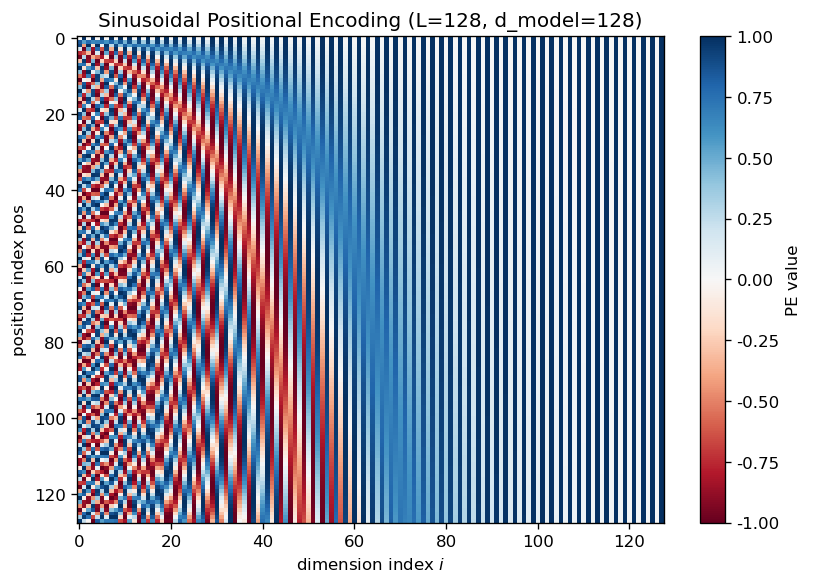

In [11]:
# 位置编码频率热力图
pe = sinusoidal_position_encoding(L=128, d_model=128).cpu().numpy()

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
im = ax.imshow(pe, aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
ax.set_xlabel("dimension index $i$")
ax.set_ylabel("position index pos")
ax.set_title("Sinusoidal Positional Encoding (L=128, d_model=128)")
plt.colorbar(im, ax=ax, label="PE value")
plt.tight_layout()
plt.show()

**【现象锚定】** 观察上方 PE 矩阵热力图：(1) 沿 dimension 轴从左到右，正弦分量的频率呈现什么变化？(2) 沿 position 轴从上到下，高频维度（图左侧）与低频维度（图右侧）的色带宽度差异说明了什么物理含义？(3) 这种"频率从高到低渐变"的编码方式如何为模型提供绝对位置与相对位置两种信息？请用 3–5 句完整段落作答。

**【请填写】** 在下方 Markdown cell 中作答。

从上方热力图可以看到，沿 dimension 轴从左到右，颜色振荡由密集逐渐变稀疏，说明正弦/余弦分量的频率从高频逐步过渡到低频。沿 position 轴从上到下，左侧高频维度的色带更窄，表示位置稍有变化编码值就明显改变；右侧低频维度的色带更宽，表示这些维度记录更慢尺度、更长波长的位置变化。多种频率叠加后，每个绝对位置都会得到一个相对独特的向量模式，因此提供绝对位置信号；同时 $\sin(pos+k)$ 和 $\cos(pos+k)$ 可以由 $\sin(pos)$、$\cos(pos)$ 线性组合表示，所以模型也能通过线性层学习固定偏移 $k$ 对应的相对位置关系。


## 7. 最小化 Transformer Block 组装

本节将 §4–§6 的算子拼装为一个完整的 Encoder-style Transformer Block，含残差连接、LayerNorm 与 FFN。

**【请填写】**：根据 §2.4–§2.7 的公式，在下方围栏内补全 `TransformerBlock.forward`。

In [ ]:
class TransformerBlock(nn.Module):
    """Encoder-style Transformer Block: Pre-LN + MHA + FFN + 残差。"""

    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float = 0.0):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model),
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, mask: torch.Tensor = None) -> torch.Tensor:
        """Pre-LN 风格：每个子层先 LN 再做主体运算，最后残差。"""
        # ==========================
        # 【请填写】组装 Pre-LN Transformer Block
        # 提示：
        # 1. 自注意力分支: x = x + Dropout(MHA(LN(x), LN(x), LN(x), mask))
        # 2. FFN 分支: x = x + Dropout(FFN(LN(x)))
        # 3. MHA 返回 (out, attn) 二元组，残差只用 out
        # ==========================
        h = self.ln1(x)
        attn_out, _ = self.mha(h, h, h, mask)
        x = x + self.drop(attn_out)
        out = x + self.drop(self.ffn(self.ln2(x)))
        # ==========================
        return out


# 【维度自检】Block 形状不变性
_block = TransformerBlock(d_model=32, num_heads=4, d_ff=64)
_X = torch.randn(2, 10, 32)
_Y = _block(_X)
assert _Y.shape == _X.shape, f"shape error: {_Y.shape}"
print("=> Transformer Block 维度校验通过！")


=> Transformer Block 维度校验通过！


## 8. 预训练 BERT 注意力探查

本节加载工业级预训练 BERT 模型，提取真实文本的注意力分布与上下文敏感表征，验证 §2.4 中 Encoder-only 模型的语言学先验是否真的从语料中习得。

### 8.1 模型加载（带优雅降级）

**【请填写】**：在下方围栏内补全 BERT 加载逻辑。

In [ ]:
try:
    from transformers import AutoTokenizer, AutoModel
except Exception as e:
    print(f"transformers 未安装或导入失败：{e}")
    AutoTokenizer, AutoModel = None, None

MODEL_NAME = "bert-base-uncased"
tokenizer, bert = None, None

if AutoTokenizer is not None and AutoModel is not None:
    # ==========================
    # 【请填写】加载 tokenizer 与模型，迁移到 device 并切换 eval 模式
    # 提示：
    # 1. tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    # 2. bert 加载时传入 output_attentions=True 才能拿到 attention 矩阵
    # 3. bert.to(device).eval()，注意 BERT 仅做前向，禁用 grad
    # ==========================
    try:
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
        try:
            bert = AutoModel.from_pretrained(
                MODEL_NAME, output_attentions=True, attn_implementation="eager"
            )
        except (TypeError, ValueError):
            bert = AutoModel.from_pretrained(MODEL_NAME, output_attentions=True)
        bert.to(device).eval()
    except Exception as e:
        print(f"BERT 加载失败：{type(e).__name__}: {e}")
        tokenizer, bert = None, None
    # ==========================

if bert is not None:
    print(f"=> Loaded {MODEL_NAME} on {device}; layers={bert.config.num_hidden_layers}, heads={bert.config.num_attention_heads}")
else:
    print("=> BERT 未加载，本节后续单元将自动跳过。")


=> Loaded bert-base-uncased on cuda; layers=12, heads=12


### 8.2 单层注意力热力图

提取一句话在指定层、指定头的注意力矩阵并可视化。

**【请填写】**：在下方围栏内补全 `extract_attention`。

In [ ]:
@torch.no_grad()
def extract_attention(text: str, layer: int, head: int):
    """返回指定层指定头的注意力矩阵 (L, L) 与对应 token 列表。"""
    attn_mat, tokens = None, None
    if bert is None or tokenizer is None:
        return attn_mat, tokens

    # ==========================
    # 【请填写】tokenize -> 前向 -> 取出 attentions[layer][0, head]
    # 提示：
    # 1. inputs = tokenizer(text, return_tensors="pt").to(device)
    # 2. outputs = bert(**inputs); attentions = outputs.attentions  # tuple[L_layers]
    # 3. attentions[layer] 形状为 (B, num_heads, L, L)
    # 4. tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    # ==========================
    inputs = tokenizer(text, return_tensors="pt").to(device)
    outputs = bert(**inputs, output_attentions=True)
    attentions = outputs.attentions
    attn_mat = attentions[layer][0, head].detach().cpu()
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].detach().cpu())
    # ==========================
    return attn_mat, tokens


SENTENCE = "the cat sat on the mat because it was tired"
LAYER, HEAD = 8, 10
# 提示：若该组合分布不显著，可尝试 layer ∈ {4..8}, head ∈ {0..11}，不同头有不同语言学专长
attn_mat, tokens = extract_attention(SENTENCE, layer=LAYER, head=HEAD)
print(f"=> tokens = {tokens}")
print(f"=> attn shape = {None if attn_mat is None else tuple(attn_mat.shape)}")


=> tokens = ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', 'because', 'it', 'was', 'tired', '[SEP]']
=> attn shape = (12, 12)


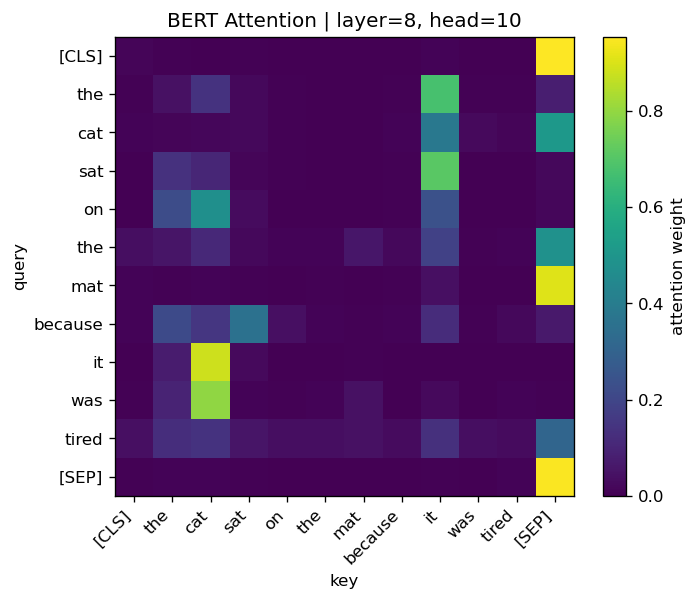

In [ ]:
if attn_mat is not None:
    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    im = ax.imshow(attn_mat.cpu().numpy(), cmap="viridis", vmin=0)
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha="right")
    ax.set_yticklabels(tokens)
    ax.set_xlabel("key")
    ax.set_ylabel("query")
    ax.set_title(f"BERT Attention | layer={LAYER}, head={HEAD}")
    plt.colorbar(im, ax=ax, label="attention weight")
    plt.tight_layout()
    plt.show()
else:
    print("=> 跳过可视化：BERT 未加载。")

**【现象锚定】** 观察上方注意力热力图（若 BERT 未加载，请基于一般 Transformer 注意力分布的常见结构作答）：(1) 代词 `it` 这一行（query）在哪些 token 上获得了最高的注意力权重？(2) 这一分布是否与人类对该句指代关系的判断（`it` 指 `cat`）一致？

**【请填写】** 在下方 Markdown cell 中作答。

本次运行成功加载 BERT，token 序列为 `['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', 'because', 'it', 'was', 'tired', '[SEP]']`，注意力矩阵形状为 `(12, 12)`。在指定的 `layer=8, head=10` 中，`it` 这一行最高的注意力权重落在 `cat` 上，权重约为 `0.880483`；后续较高的 token 是 `the`（约 `0.072860`）、`sat`（约 `0.025990`）、`mat`（约 `0.006958`）和 `tired`（约 `0.002946`）。这一分布与人类对该句的共指判断一致，因为 “because it was tired” 中的 `it` 更自然地指向前文的 `cat`。不过这仍然只是单层单头的可解释性证据，不能把一个 attention head 直接等同于完整的共指解析模块；它说明该头在这个句子上确实学到了很强的实体指向线索。


### 8.3 多义词上下文敏感性

通过同一词在两种不同语境下的 BERT 表征余弦相似度，验证 Encoder-only 模型是否真的提供"上下文相关"嵌入。

**【请填写】**：在下方围栏内补全 `contextual_embedding`。

In [ ]:
@torch.no_grad()
def contextual_embedding(text: str, target: str, layer: int = -1) -> torch.Tensor:
    """提取 target 词在 text 中的上下文相关嵌入（指定层最后一个 sub-token 的隐藏态）。"""
    h = None
    if bert is None or tokenizer is None:
        return h

    # ==========================
    # 【请填写】定位 target 在 token 序列中的位置并提取对应隐藏态
    # ==========================
    inputs = tokenizer(text, return_tensors="pt").to(device)
    outputs = bert(**inputs, output_hidden_states=True)
    hidden = outputs.hidden_states[layer]

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].detach().cpu())
    target_tokens = tokenizer.tokenize(target)
    target_index = None
    for i in range(len(tokens) - len(target_tokens) + 1):
        if tokens[i:i + len(target_tokens)] == target_tokens:
            target_index = i + len(target_tokens) - 1
            break

    if target_index is None:
        normalized = [tok.replace("##", "") for tok in tokens]
        for i, tok in enumerate(normalized):
            if tok == target.lower():
                target_index = i
                break

    if target_index is None:
        return None

    h = hidden[0, target_index].detach().cpu()
    # ==========================
    return h


TEXT_BANK_SIDE = "I sat on the river bank and watched the boats."
TEXT_FINANCE = "I deposited my paycheck at the bank yesterday."
TEXT_BANK_AGAIN = "We had a picnic by the river bank in summer."

if bert is not None:
    e1 = contextual_embedding(TEXT_BANK_SIDE, "bank")
    e2 = contextual_embedding(TEXT_FINANCE, "bank")
    e3 = contextual_embedding(TEXT_BANK_AGAIN, "bank")
    if e1 is not None and e2 is not None and e3 is not None:
        cos = nn.functional.cosine_similarity
        print(f"=> cos(river-bank, river-bank) = {cos(e1, e3, dim=-1).item():.4f}")
        print(f"=> cos(river-bank, finance-bank) = {cos(e1, e2, dim=-1).item():.4f}")
    else:
        print("=> 嵌入提取失败，请检查实现。")
else:
    print("=> 跳过：BERT 未加载。")


=> cos(river-bank, river-bank) = 0.8406
=> cos(river-bank, finance-bank) = 0.4704


**【结果锚定】** 观察上方两个余弦相似度：(1) 同义场景（两次 `river bank`）的余弦相似度与异义场景（`river bank` vs `finance bank`）的相似度差距有多大？(2) 若把对比对象换成同义但句法位置不同的两次出现（如 `the bank` vs `a bank`），你预期相似度会显著下降还是基本持平？请用 3–5 句完整段落作答。

**【请填写】** 在下方 Markdown cell 中作答。

本次运行中，`cos(river-bank, river-bank)=0.8406`，而 `cos(river-bank, finance-bank)=0.4704`，同义场景比异义场景高约 `0.3702`。这说明 BERT 给出的不是静态词向量：同样是 `bank`，当上下文包含 `river`、`boats`、`picnic` 等河岸语义时，隐藏态更接近；当上下文变成 `deposited`、`paycheck` 等金融语义时，隐藏态明显偏离。若对比对象换成同义但句法位置略有不同的两次出现，例如 `the bank` 与 `a bank` 都表示金融机构或都表示河岸，我预期相似度会基本持平而不是显著下降。冠词和句法位置会带来小幅表征差异，但不会像“河岸”和“银行”这种词义改变一样造成明显分离。


## 9. 思考与附加题

本节每条均要求 3–5 句完整段落作答。

### 9.1 必做题目

**【理论锚定】** LayerNorm 在 NLP 序列任务中相较 BatchNorm 的优势。请论证：（1）变长序列的 padding 如何污染 BatchNorm 的批次统计；（2）小批量训练下 BatchNorm 滑动均值的偏差；

**【请填写】** 在下方 Markdown cell 中作答。

LayerNorm 更适合 NLP 序列任务，首先是因为变长序列通常需要 padding 到同一长度，而 BatchNorm 沿 batch 维统计均值和方差时会把 padding token 的激活也混入统计量。即使使用 mask，BatchNorm 在不同 batch 中有效 token 数和长度分布变化很大，统计量仍会随样本组合波动，使归一化结果依赖当前 batch 的偶然结构。小批量训练时 BatchNorm 的滑动均值和方差估计方差更大，若 batch 内句子主题、长度或 padding 比例不稳定，推理时使用的 running statistics 就会偏离真实分布。LayerNorm 则在单个 token 的特征维度内部归一化，不依赖其他样本，也不依赖 batch 中 padding 的比例，因此与 Transformer 中 token-wise 的注意力和变长文本处理更匹配。


**【理论锚定】** Encoder-only / Decoder-only / Encoder-Decoder 三种范式的归纳偏置与下游任务匹配关系。请论证：（1）双向 vs 因果掩码如何决定可承担任务的方向性；（2）为什么"理解类任务"用 Encoder-only、"生成类任务"用 Decoder-only、"序列到序列任务"用 Encoder-Decoder 是当前实践的主流；（3）若强行用 Decoder-only 做分类，会牺牲什么；若用 Encoder-only 做开放式生成，又会牺牲什么。

**【请填写】** 在下方 Markdown cell 中作答。

Encoder-only、Decoder-only 与 Encoder-Decoder 的核心差异来自注意力可见性：Encoder-only 使用双向自注意力，每个 token 可以同时看到左右上下文，因此天然适合分类、匹配、抽取、序列标注等理解类任务；Decoder-only 使用因果掩码，每个位置只能看见过去 token，因此它的归纳偏置与从左到右生成下一个 token 完全一致。Encoder-Decoder 则把输入理解和输出生成分成两个模块，encoder 双向编码源序列，decoder 在因果生成的同时通过 cross-attention 读取源序列，所以机器翻译、摘要、问答生成等序列到序列任务常采用这种结构。若强行用 Decoder-only 做分类，通常需要把分类结果转化为最后位置或标签 token 的生成，模型不能在中间层双向同时审视整句，样本效率和判别式建模直接性会受损。若用 Encoder-only 做开放式生成，它没有原生的因果自回归训练目标和逐步生成掩码，直接生成会缺少从左到右的概率分解机制，必须额外改造或采用非自然的填空式生成，流畅性和可控长度都会受影响。


### 9.2 附加题（选做，分数不溢出）

**【理论锚定】** 注意力的二次复杂度 $\mathcal{O}(L^2 d)$ 是长上下文的瓶颈。请任选一条现代变体（线性注意力、稀疏注意力、滑动窗口注意力、FlashAttention 中的任意一种）并论证：（1）它如何在数学定义上规避或缓解 $L^2$ 项；（2）这种规避是以什么"建模能力"为代价交换的。

**【请填写】** 在下方 Markdown cell 中作答。

我选择 FlashAttention 作为长上下文注意力变体。标准注意力先显式构造 $\mathbf{S}=\mathbf{Q}\mathbf{K}^\top\in\mathbb{R}^{L\times L}$ 和 $\mathbf{A}=\mathrm{softmax}(\mathbf{S})$，显存读写与中间矩阵存储都会受到 $L^2$ 项限制；FlashAttention 在数学定义上仍计算精确的 $\mathrm{softmax}(\mathbf{Q}\mathbf{K}^\top/\sqrt{d})\mathbf{V}$，但把 $Q,K,V$ 分块载入高速 SRAM，并用在线 softmax 维护每一行的最大值和归一化因子，从而避免把完整 $L\times L$ 注意力矩阵写入显存。它缓解的主要是显存占用和显存 IO 瓶颈，而不是把理论乘法次数完全降到线性，因此更准确地说它是硬件感知的精确注意力实现。与线性注意力或稀疏注意力不同，FlashAttention 基本不牺牲全局建模能力，因为每个 query 仍可关注所有 key；它付出的代价主要是实现复杂度更高、对 GPU kernel 和硬件特性更敏感，并且在某些自定义 mask、特殊 attention 变体或小规模输入上不一定比普通实现更方便。


*实验五到此结束。请确认所有必填项已完成并提交本 Notebook。*